In [1]:
import sys
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


def process_csv(path: Path) -> pl.DataFrame:
    df = pl.read_csv(path)
    df.columns = [
        "page_number",
        "uncompressed_size",
        "compressed_size",
        "compression_time",
        "decompression_time"]
    
    test, compressor = path.stem.split("_")
    df = df.with_columns(alg = pl.lit(compressor))
    df = df.with_columns(test = pl.lit(test))

    return df


In [2]:
compressors = ["lz4", "WKdm", "zlib", "WK64", "lzo", "zstd"]
dfs = []
for c in compressors:
    dfs.append(process_csv(Path(f"../data/ollama_{c}.csv")))

df3 = pl.concat(dfs)
curr_df = df3

Text(0.5, 1.05, 'Compressed size in B vs. frequency')

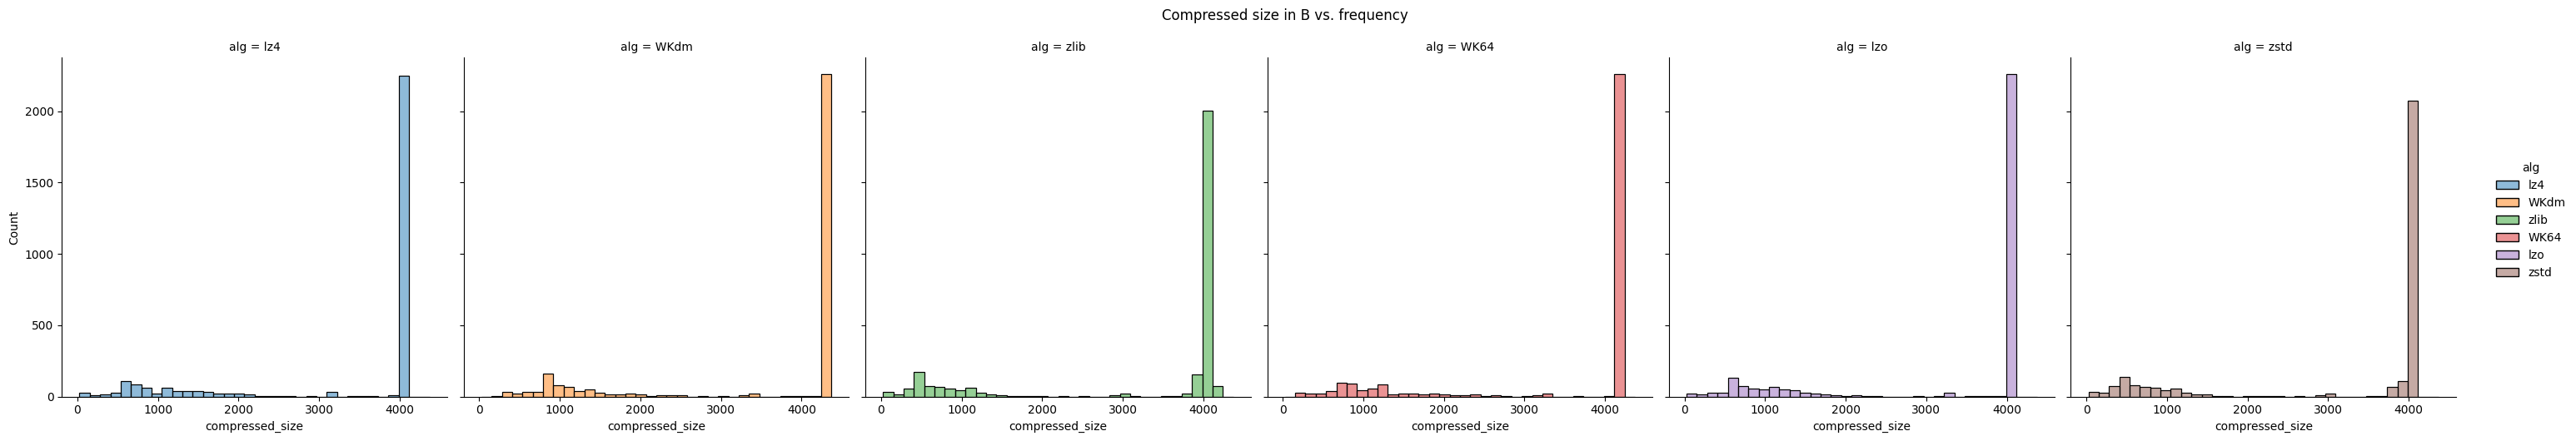

In [3]:
g = sns.displot(
    data=curr_df, 
    x="compressed_size", 
    binwidth=128, 
    hue="alg",
    col="alg")
g.fig.suptitle("Compressed size in B vs. frequency", y=1.05)